In [2]:
import numpy as np
def read_cebaf(filename):
    data = np.load(filename)
    nentries = int(data.shape[0]/3)
    heat = data[0:nentries]
    trip = data[nentries:2*nentries]
    alpha = data[2*nentries:3*nentries] 
    return heat,trip,alpha

In [39]:
import os
import matplotlib.pyplot as plt
def make_images():# Path
    ga_data = np.load('1L10_TEST8_nsga_II_results.npy')
    ga_index = np.argsort(ga_data[:,0])
    ga_heat = ga_data[:,0]
    ga_trip = ga_data[:,1]
    path = "../drivers/results"
    for i in range(1000):  
        counter = (i+1)*5000
        # Join various path components
        file = f'inference_results_steps{counter}.npy'
        mf_heat, mf_trip, mf_alpha = read_cebaf(os.path.join(path,
                                                             'index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash9e9af1c_results_20240731-191418',
                                                             file))
        mb_heat, mb_trip, mb_alpha = read_cebaf(os.path.join(path,
                                                     'index0_agent_MO-KerasMB-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC-TF_hashb858d1e_results_20240807-211512',
                                                     file))
        fig, ax = plt.subplots(dpi=150)
        plt.scatter(mf_heat, mf_trip, c=mf_alpha, marker='o', s=25, edgecolors='black', alpha=0.75, label="Model-Free MORL")
        plt.scatter(mb_heat, mb_trip, c=mb_alpha, marker='o', s=25, edgecolors='red', alpha=0.75, label="Model-Diff MORL")
        plt.plot(ga_heat[ga_index], ga_trip[ga_index], c='black', linestyle='dashed', label="NSGA-II")

        # Format
        plt.legend()
        plt.grid()
        plt.xlim(20.8,22.2)
        plt.ylim(0.015,0.04)        
        plt.xlabel('Heat Load [W]')
        plt.ylabel('Trip Rate [per hour]');
        plt.colorbar()
        plt.tight_layout()
        plt.savefig(f'movie/cebaf_mo{counter}.jpg')
        plt.close()
make_images()

FileNotFoundError: [Errno 2] No such file or directory: '../drivers/results/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash9e9af1c_results_20240731-191418/inference_results_steps1000000.npy'

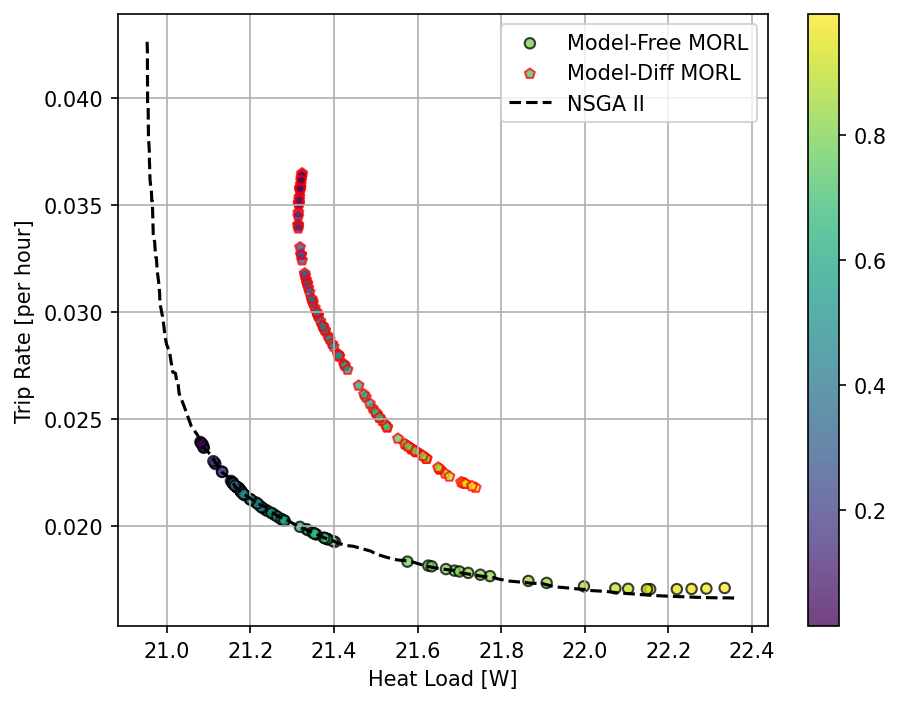

In [19]:
# mf_heat, mf_trip, mf_alpha = read_cebaf('../drivers/results'
#                +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash4cc092e_results_20240731-145258'
#                +'/inference_results_steps250000.npy')
mf_heat, mf_trip, mf_alpha = read_cebaf('../drivers/results'
               +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash9e9af1c_results_20240731-191418'
               +'/inference_results_steps200000.npy')

mb_heat, mb_trip, mb_alpha = read_cebaf('../drivers/results'
               +'/index0_agent_MO-KerasMB-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC-TF_hashb858d1e_results_20240807-180125'
               +'/inference_results_steps10100.npy')
ga_data = np.load('1L10_TEST8_nsga_II_results.npy')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(dpi=150)
plt.scatter(mf_heat, mf_trip, c=mf_alpha, marker='o', s=25, edgecolors='black', alpha=0.75, label="Model-Free MORL")
plt.scatter(mb_heat, mb_trip, c=mb_alpha, marker='p', s=25, edgecolors='red', alpha=0.75, label="Model-Diff MORL")
ga_index = np.argsort(ga_data[:,0])
ga_heat = ga_data[:,0]
ga_trip = ga_data[:,1]
plt.plot(ga_heat[ga_index], ga_trip[ga_index], c='black', linestyle='dashed', label="NSGA II")
plt.legend()
plt.grid()
plt.xlabel('Heat Load [W]')
plt.ylabel('Trip Rate [per hour]');
plt.colorbar()
plt.tight_layout()
plt.savefig('movie/cebaf_mo.jpg')

In [18]:
data = np.load('1L10_TEST8_nsga_II_results.npy')
print(data.shape)

(128, 2)


(190,)
(190,)
(190,)


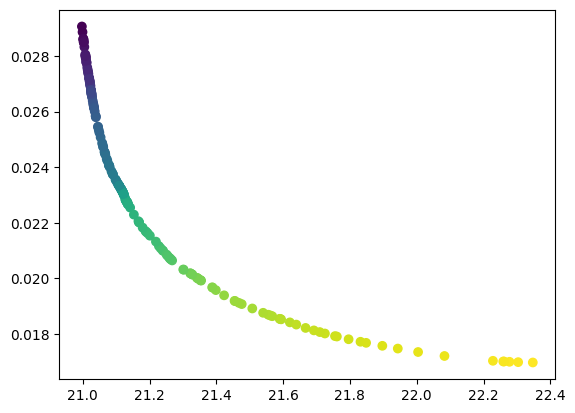

In [38]:
import numpy as np
data = np.load('../drivers/results'
               +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash4cc092e_results_20240731-145258'
               +'/inference_results_steps250000.npy')
nentries = int(data.shape[0]/3)
heat = data[0:nentries]
trip = data[nentries:2*nentries]
alpha = data[2*nentries:3*nentries]
print(heat.shape)
print(trip.shape)
print(alpha.shape)
# print(data[0:nentries])
# data = data.reshape(nentries,-1)
# print(data.shape)
# print(data[:,0])
import matplotlib.pyplot as plt
plt.scatter(heat, trip, c=alpha, marker='o')